import libraries


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

load dataset

In [ ]:
df = pd.read_excel('/content/EastWestAirlines (1).xlsx', sheet_name='data')

In [ ]:
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [ ]:
df.shape

(3999, 12)

statistical summary

In [ ]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


missing values

In [ ]:
df.isnull().sum()

,0
ID#,0
Balance,0
Qual_miles,0
cc1_miles,0
cc2_miles,0
cc3_miles,0
Bonus_miles,0
Bonus_trans,0
Flight_miles_12mo,0
Flight_trans_12,0


duplicate values

In [ ]:
df.duplicated().sum()

np.int64(0)

removing column

In [ ]:
df = df.drop('ID#', axis=1)

checking outliers

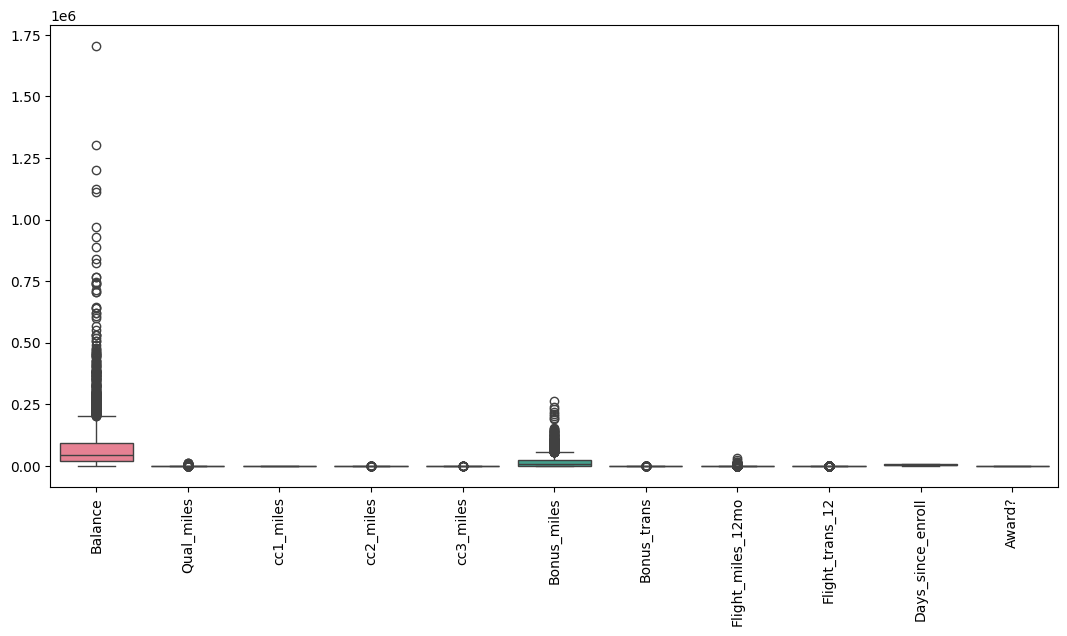

In [ ]:
plt.figure(figsize=(13,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

histograms

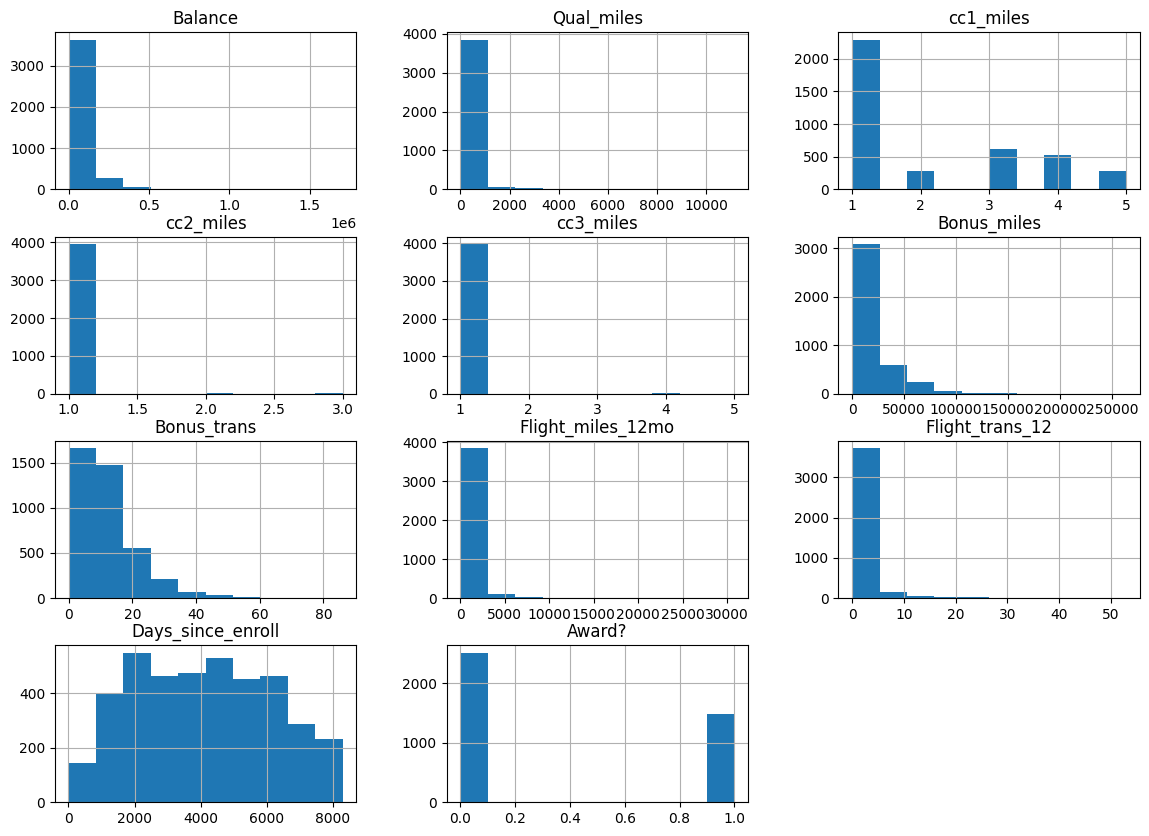

In [ ]:
df.hist(figsize=(14,10))
plt.show()

correlation heatmap

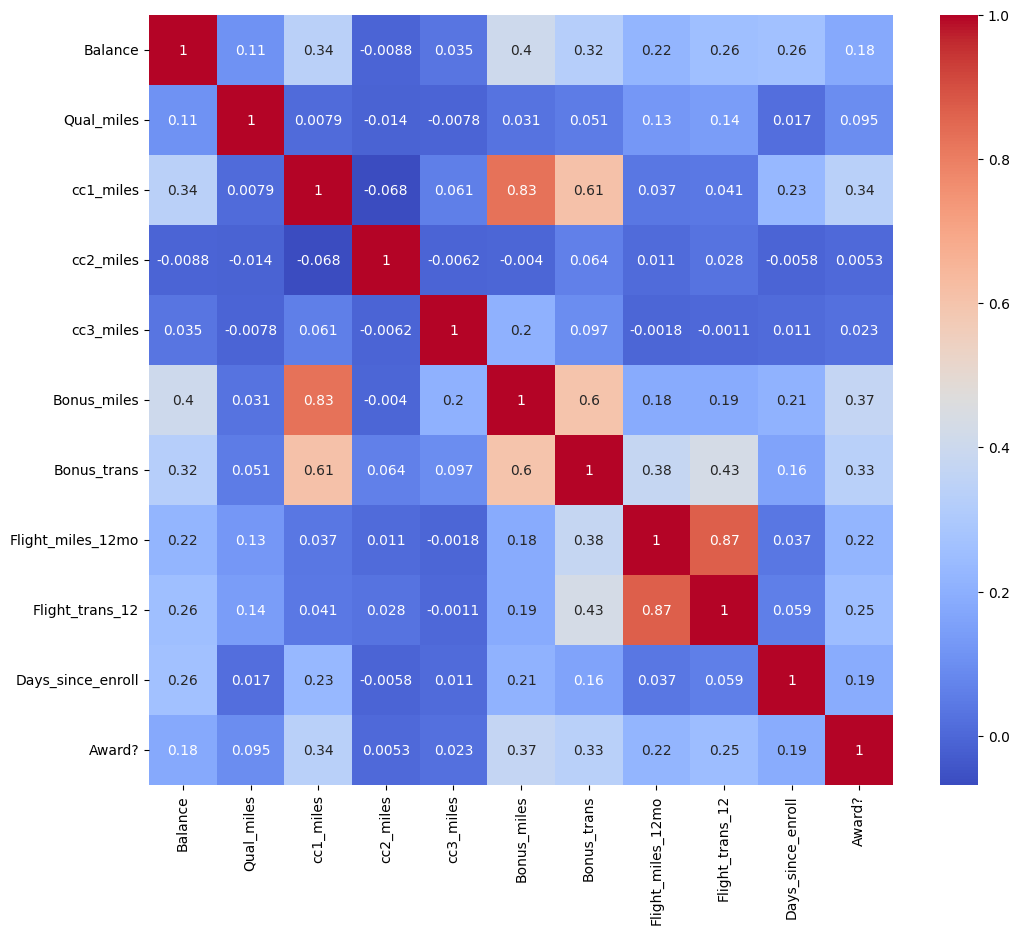

In [ ]:
plt.figure(figsize=(12,10))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.show()

feature scaling

In [ ]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled_data,
                         columns=df.columns)

scaled_df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-0.451141,-0.186299,-0.769578,-0.098242,-0.062767,-0.702786,-1.104065,-0.328603,-0.362168,1.395454,-0.766919
1,-0.539457,-0.186299,-0.769578,-0.098242,-0.062767,-0.701088,-0.999926,-0.328603,-0.362168,1.379957,-0.766919
2,-0.320031,-0.186299,-0.769578,-0.098242,-0.062767,-0.539253,-0.791649,-0.328603,-0.362168,1.411920,-0.766919
3,-0.583799,-0.186299,-0.769578,-0.098242,-0.062767,-0.689286,-1.104065,-0.328603,-0.362168,1.372208,-0.766919
4,0.239678,-0.186299,1.409471,-0.098242,-0.062767,1.083121,1.499394,1.154932,0.692490,1.363975,1.303918


elbow method for k-means


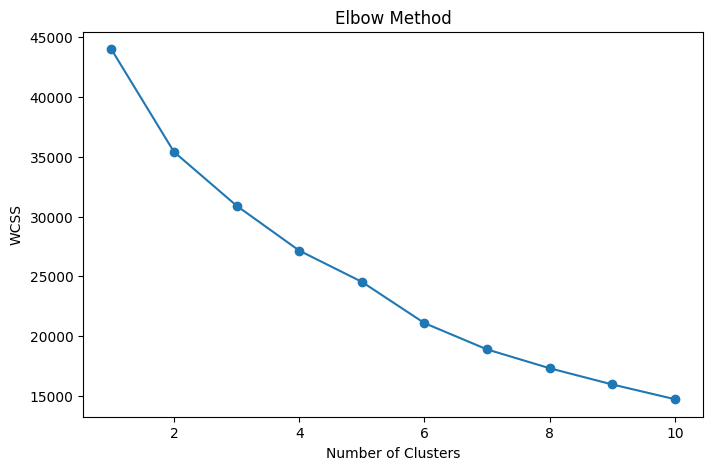

In [ ]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_df)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11),
         wcss,
         marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()


k-means clustering

In [ ]:
kmeans = KMeans(
    n_clusters=5,
    random_state=40,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(scaled_df)

scaled_df["KMeans_Cluster"] = kmeans_labels

In [ ]:
scaled_df["KMeans_Cluster"].value_counts()

,count
KMeans_Cluster,
1,2507
0,1270
2,164
4,43
3,15


In [ ]:
score = silhouette_score(
    scaled_df.drop("KMeans_Cluster",axis=1),
    kmeans_labels
)

print(score)

0.32379286604843893


visualize k-means

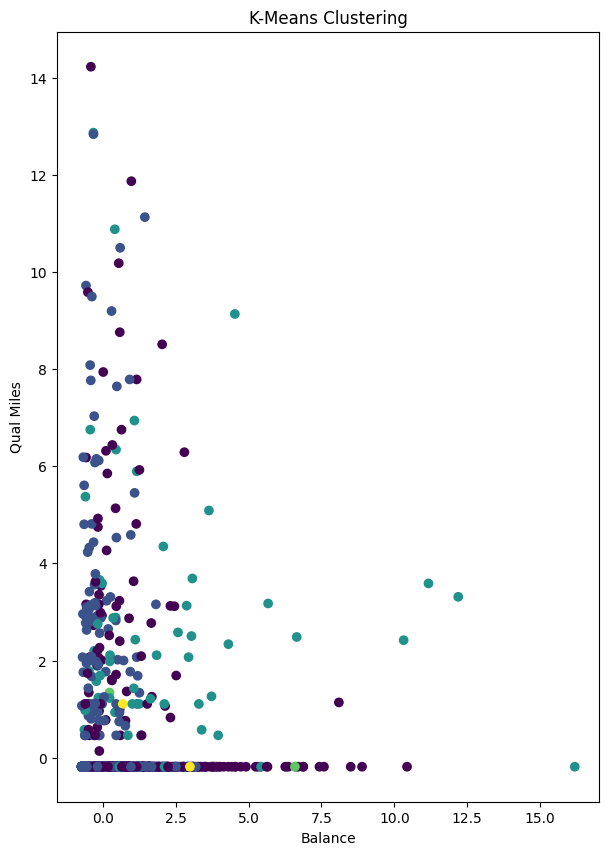

In [ ]:
plt.figure(figsize=(7,10))

plt.scatter(
    scaled_df.iloc[:,0],
    scaled_df.iloc[:,1],
    c=kmeans_labels,
    cmap='viridis'
)

plt.xlabel("Balance")
plt.ylabel("Qual Miles")

plt.title("K-Means Clustering")

plt.show()

DBSCAN clustering

In [ ]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=8
)

db_labels = dbscan.fit_predict(
    scaled_df.drop("KMeans_Cluster",axis=1)
)

scaled_df["DBSCAN_Cluster"] = db_labels

In [ ]:
scaled_df["DBSCAN_Cluster"].value_counts()

,count
DBSCAN_Cluster,
0,2399
1,1218
-1,359
2,15
3,8


silhouette score for DBSCAN

In [ ]:
mask = db_labels != -1

score_db = silhouette_score(
    scaled_df.drop(
        ["KMeans_Cluster","DBSCAN_Cluster"],
        axis=1
    )[mask],
    db_labels[mask]
)

print(score_db)


0.29861662770392655


DBSCAN visualization

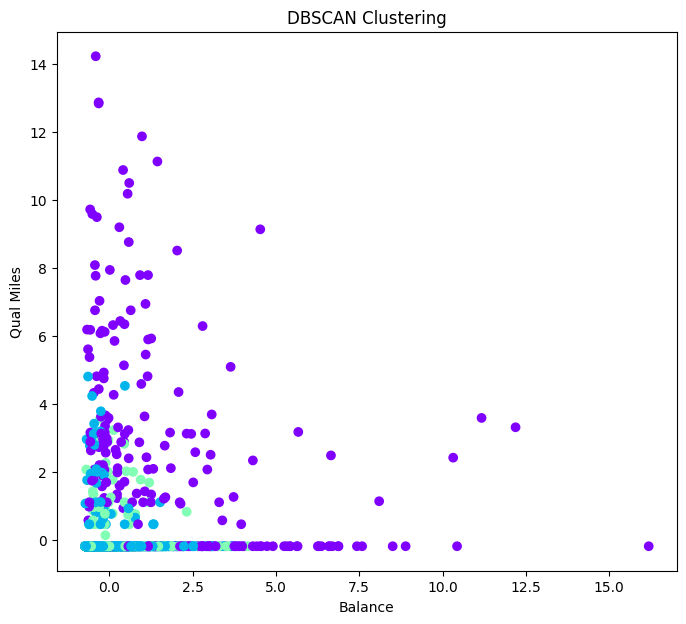

In [ ]:
plt.figure(figsize=(8,7))

plt.scatter(
    scaled_df.iloc[:,0],
    scaled_df.iloc[:,1],
    c=db_labels,
    cmap='rainbow'
)

plt.xlabel("Balance")
plt.ylabel("Qual Miles")

plt.title("DBSCAN Clustering")

plt.show()

different k values

In [ ]:
for k in [2,3,4,5,6]:

    model = KMeans(
        n_clusters=k,
        random_state=40,
        n_init=10
    )

    labels = model.fit_predict(scaled_df.drop(
        ["KMeans_Cluster","DBSCAN_Cluster"],
        axis=1,
        errors='ignore'
    ))

    score = silhouette_score(
        scaled_df.drop(
            ["KMeans_Cluster","DBSCAN_Cluster"],
            axis=1,
            errors='ignore'
        ),
        labels
    )

    print("K =",k,
          "Silhouette =",round(score,3))

K = 2 Silhouette = 0.325
K = 3 Silhouette = 0.312
K = 4 Silhouette = 0.311
K = 5 Silhouette = 0.324
K = 6 Silhouette = 0.279


DBSCAN parameters

In [ ]:
eps_values=[0.8,1.0,1.2,1.5,2.0]

for eps in eps_values:

    db=DBSCAN(
        eps=eps,
        min_samples=8
    )

    labels=db.fit_predict(
        scaled_df.drop(
            ["KMeans_Cluster","DBSCAN_Cluster"],
            axis=1,
            errors='ignore'
        )
    )

    clusters=len(set(labels))-(
        1 if -1 in labels else 0
    )

    print("eps =",eps,
          "Clusters =",clusters)

eps = 0.8 Clusters = 3
eps = 1.0 Clusters = 3
eps = 1.2 Clusters = 4
eps = 1.5 Clusters = 4
eps = 2.0 Clusters = 4


clustesr analysis

In [ ]:
cluster_analysis = df.copy()

cluster_analysis["Cluster"] = kmeans_labels

cluster_analysis.groupby("Cluster").mean()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
Cluster,,,,,,,,,,,
0,116739.909449,155.122047,3.704724,1.000000,1.001575,39234.801575,18.740945,334.584252,0.997638,4896.661417,0.648031
1,43843.558436,98.836059,1.224970,1.000000,1.000399,4601.245712,6.808935,197.764260,0.615078,3687.849222,0.199840
2,189778.103659,788.689024,2.189024,1.000000,1.000000,31452.060976,26.524390,5404.835366,15.640244,4671.030488,0.804878
3,138061.400000,78.800000,3.466667,1.000000,4.066667,93927.866667,28.066667,506.666667,1.600000,4613.866667,0.533333
4,68876.581395,23.255814,1.139535,2.348837,1.000000,14689.837209,17.534884,582.627907,2.209302,3968.930233,0.395349
